# Data Cleaning, Exploratory Data Analysis, and Merging

This section is for cleaning, analyzing, and merging two tweet sentiment datasets.

In [1]:

# loading libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Configure display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [2]:
# Loading datasets
df_provided = pd.read_csv('data/Provided.csv', encoding='latin-1')
df_data2 = pd.read_csv('data/Data2.csv', encoding='latin-1')


In [3]:
df_provided.head()

,tweet_text,emotion_in_tweet_is_directed_at,is_there_an_emotion_directed_at_a_brand_or_product
0,.@wesley83 I have a 3G iPhone. After 3 hrs twe...,iPhone,Negative emotion
1,@jessedee Know about @fludapp ? Awesome iPad/i...,iPad or iPhone App,Positive emotion
2,@swonderlin Can not wait for #iPad 2 also. The...,iPad,Positive emotion
3,@sxsw I hope this year's festival isn't as cra...,iPad or iPhone App,Negative emotion
4,@sxtxstate great stuff on Fri #SXSW: Marissa M...,Google,Positive emotion


In [4]:
df_provided.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9093 entries, 0 to 9092
Data columns (total 3 columns):
 #   Column                                              Non-Null Count  Dtype 
---  ------                                              --------------  ----- 
 0   tweet_text                                          9092 non-null   object
 1   emotion_in_tweet_is_directed_at                     3291 non-null   object
 2   is_there_an_emotion_directed_at_a_brand_or_product  9093 non-null   object
dtypes: object(3)
memory usage: 213.2+ KB


In [5]:
df_provided.shape

(9093, 3)

In [6]:
df_data2.head()

,id,date,text,target
0,0,6/20/2009,My concealer just broke!,0
1,1,6/21/2009,Mommy leaves soon,0
2,2,6/3/2009,@Boogaloo1 Not here it ain't! I've got an epi...,0
3,3,6/16/2009,I want my Blackberry back!!,0
4,4,6/16/2009,@Veganluke I can't even skype still dont have...,0


In [7]:
df_data2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      10000 non-null  int64 
 1   date    10000 non-null  object
 2   text    10000 non-null  object
 3   target  10000 non-null  int64 
dtypes: int64(2), object(2)
memory usage: 312.6+ KB


In [8]:
df_data2.shape

(10000, 4)

## Data Cleaning: Dataset 1 (Provided.csv)

Cleaning the first dataset by removing duplicates, handling missing values, and standardizing emotion labels.

In [9]:
df1 = df_provided.copy()

In [10]:
# Checking for missing values
df1.isnull().sum().sum()

np.int64(5803)

In [11]:
# Checking for duplicates
df1.duplicated().sum()

np.int64(22)

In [12]:
# Remove rows where tweet_text is missing
df1 = df1[df1['tweet_text'].notna()].copy()

In [13]:
# Clean text first
df1['tweet_text'] = df1['tweet_text'].str.strip()
df1['tweet_text_clean'] = df1['tweet_text'].str.lower()

In [14]:
# Remove duplicates based on tweet_text
df1 = df1.drop_duplicates(subset=['tweet_text']).copy()

In [15]:
# Handle missing categorical values
df1['emotion_in_tweet_is_directed_at'] = df1['emotion_in_tweet_is_directed_at'].fillna('Unknown')
df1['is_there_an_emotion_directed_at_a_brand_or_product'] = df1['is_there_an_emotion_directed_at_a_brand_or_product'].fillna('Unknown')


In [16]:
# Handle missing values in categorical columns
df1['emotion_in_tweet_is_directed_at'] = df1['emotion_in_tweet_is_directed_at'].fillna('Unknown')
df1['is_there_an_emotion_directed_at_a_brand_or_product'] = df1['is_there_an_emotion_directed_at_a_brand_or_product'].fillna('Unknown')


In [17]:
# Standardize emotion labels
emotion_mapping = {
    'Negative emotion': 'Negative',
    'Positive emotion': 'Positive',
    'No emotion toward brand or product': 'Neutral',
    "I can't tell": 'Uncertain',
    'Unknown': 'Unknown'
}

df1['is_there_an_emotion_directed_at_a_brand_or_product'] = (df1['is_there_an_emotion_directed_at_a_brand_or_product']
    .map(emotion_mapping).fillna('Unknown'))


In [18]:
# Add features
df1['dataset_source'] = 'Provided'
df1['text_length'] = df1['tweet_text'].str.len()
df1['word_count'] = df1['tweet_text'].str.split().str.len()

In [19]:
df1.shape

(9065, 7)

In [20]:
df1.isnull().sum().sum()

np.int64(0)

In [21]:
df1.duplicated(subset=['tweet_text']).sum()

np.int64(0)

## Data Cleaning: Dataset 2 (Data2.csv)

Cleaning the second dataset by removing duplicates, handling missing values, and standardizing sentiment labels.

In [22]:
df2 = df_data2.copy()

In [23]:
df2.isnull().sum().sum()

np.int64(0)

In [24]:
df2.duplicated().sum()

np.int64(0)

In [25]:
# Remove missing text
df2 = df2[df2['text'].notna()].copy()

In [26]:
# Clean text
df2['text'] = df2['text'].str.strip()
df2['text_clean'] = df2['text'].str.lower()

In [27]:
# Remove duplicates
df2 = df2.drop_duplicates(subset=['text_clean']).copy()

In [28]:
# Convert date
df2['date'] = pd.to_datetime(df2['date'], errors='coerce')

In [29]:
# 5. Map sentiment
sentiment_mapping = {
    0: 'Negative',
    1: 'Positive'
}
df2['sentiment'] = df2['target'].map(sentiment_mapping).fillna('Unknown')

In [30]:
# 6. Rename columns 
df2 = df2.rename(columns={'text': 'tweet_text', 'date': 'tweet_date'})

In [31]:
# 7. Add features
df2['dataset_source'] = 'Data2'
df2['text_length'] = df2['tweet_text'].str.len()
df2['word_count'] = df2['tweet_text'].str.split().str.len()

In [32]:
df2.shape

(9986, 9)

In [33]:
df2.isnull().sum().sum()

np.int64(0)

In [34]:
df2.duplicated(subset=['text_clean']).sum()

np.int64(0)

## Exploratory Data Analysis

Examining the distributions, patterns, and statistics of both cleaned datasets.

### Analysis: Dataset 1 (Brand-Specific Emotions)

Statistical summary and distribution analysis of the Provided.csv dataset with focus on brand emotions and sentiment.

In [35]:
df1.dtypes

tweet_text                                            object
emotion_in_tweet_is_directed_at                       object
is_there_an_emotion_directed_at_a_brand_or_product    object
tweet_text_clean                                      object
dataset_source                                        object
text_length                                            int64
word_count                                             int64
dtype: object

In [36]:
# Sentiment
if 'is_there_an_emotion_directed_at_a_brand_or_product' in df1.columns:
    print(df1['is_there_an_emotion_directed_at_a_brand_or_product'].value_counts())

is_there_an_emotion_directed_at_a_brand_or_product
Neutral      5372
Positive     2968
Negative      569
Uncertain     156
Name: count, dtype: int64


In [37]:
# Brand
if 'emotion_in_tweet_is_directed_at' in df1.columns:
    print(df1['emotion_in_tweet_is_directed_at'].value_counts().head(10))

emotion_in_tweet_is_directed_at
Unknown                            5785
iPad                                943
Apple                               659
iPad or iPhone App                  469
Google                              428
iPhone                              296
Other Google product or service     293
Android App                          80
Android                              77
Other Apple product or service       35
Name: count, dtype: int64


In [38]:
df1['text_length'].mean()

np.float64(104.96933259790403)

In [39]:
df1['text_length'].median()

np.float64(109.0)

In [40]:
df1['text_length'].min()

np.int64(11)

In [41]:
df1['text_length'].max()

np.int64(178)

### Analysis: Dataset 2 (General Sentiment)

Statistical summary and distribution analysis of the Data2.csv dataset with focus on general sentiment classification.

In [42]:
df2.dtypes

id                         int64
tweet_date        datetime64[ns]
tweet_text                object
target                     int64
text_clean                object
sentiment                 object
dataset_source            object
text_length                int64
word_count                 int64
dtype: object

In [43]:
df2['sentiment'].value_counts()

sentiment
Negative    4993
Positive    4993
Name: count, dtype: int64

In [44]:
df2['tweet_date'].min()

Timestamp('2009-04-06 00:00:00')

In [45]:
df2['tweet_date'].max()

Timestamp('2009-06-25 00:00:00')

In [46]:
df2['tweet_date'].isna().sum()

np.int64(0)

In [47]:
# Text stats
print(f"\nText Length Statistics:")
print(f"  Mean: {df2['text_length'].mean():.0f} chars")
print(f"  Median: {df2['text_length'].median():.0f} chars")
print(f"  Min: {df2['text_length'].min()} chars")
print(f"  Max: {df2['text_length'].max()} chars")


Text Length Statistics:
  Mean: 74 chars
  Median: 69 chars
  Min: 6 chars
  Max: 327 chars


## Merging Datasets

Standardizing column names and combining both datasets into a single unified dataset. The merged dataset consolidates all records while maintaining data integrity and adding source tracking information.

In [48]:
# Standardize Dataset 1

df1_merged = df1.copy()

# Rename for consistency
df1_merged = df1_merged.rename(columns={
    'tweet_text': 'text',
    'is_there_an_emotion_directed_at_a_brand_or_product': 'sentiment',
    'emotion_in_tweet_is_directed_at': 'target_brand',
    'dataset_source': 'source'
})

# Keep only needed columns 
cols_df1 = ['text', 'sentiment', 'target_brand', 'source', 'text_length', 'word_count']
df1_merged = df1_merged[[col for col in cols_df1 if col in df1_merged.columns]].copy()

# Add missing columns
df1_merged['tweet_id'] = pd.RangeIndex(start=1, stop=len(df1_merged)+1)
df1_merged['date'] = pd.NaT
df1_merged['sentiment_source'] = 'Brand-Specific'

In [49]:
# Standardize Dataset 2

df2_merged = df2.copy()

# Rename for consistency
df2_merged = df2_merged.rename(columns={
    'tweet_text': 'text',
    'tweet_date': 'date',
    'dataset_source': 'source'
})

# Keep only needed columns 
cols_df2 = ['text', 'sentiment', 'id', 'date', 'source', 'text_length', 'word_count']
df2_merged = df2_merged[[col for col in cols_df2 if col in df2_merged.columns]].copy()

# Rename id → tweet_id (if exists)
if 'id' in df2_merged.columns:
    df2_merged = df2_merged.rename(columns={'id': 'tweet_id'})
else:
    df2_merged['tweet_id'] = pd.RangeIndex(start=100000, stop=100000+len(df2_merged))

# Add missing columns
df2_merged['target_brand'] = 'General'
df2_merged['sentiment_source'] = 'General'


In [50]:
# Align Column Order

common_cols = [
    'text', 'sentiment', 'sentiment_source', 'target_brand',
    'source', 'text_length', 'word_count', 'tweet_id', 'date'
]

df1_final = df1_merged.reindex(columns=common_cols)
df2_final = df2_merged.reindex(columns=common_cols)

In [51]:
# Merge Datasets

merged_df = pd.concat([df1_final, df2_final], ignore_index=True)

In [52]:
# Remove duplicates (case-insensitive)
merged_df['text_clean'] = merged_df['text'].str.lower().str.strip()
merged_df = merged_df.drop_duplicates(subset=['text_clean']).copy()

In [53]:
# Total rows and columns
print(f" Total rows: {len(merged_df):,}")
print(f" Total columns: {merged_df.shape[1]}")

 Total rows: 19,033
 Total columns: 10


In [54]:
# Dataset breakdown
print(merged_df['source'].value_counts())

source
Data2       9986
Provided    9047
Name: count, dtype: int64


In [55]:
# Sentiment distribution
print(merged_df['sentiment'].value_counts())

sentiment
Positive     7958
Negative     5562
Neutral      5357
Uncertain     156
Name: count, dtype: int64


In [56]:
# Sentiment source
print(merged_df['sentiment_source'].value_counts())

sentiment_source
General           9986
Brand-Specific    9047
Name: count, dtype: int64


In [57]:
# Missing values
print(merged_df.isnull().sum())

text                   0
sentiment              0
sentiment_source       0
target_brand           0
source                 0
text_length            0
word_count             0
tweet_id               0
date                9047
text_clean             0
dtype: int64


In [58]:
# Duplicates
print(merged_df.duplicated(subset=['text_clean']).sum())

0


## Visualizations

Creating comprehensive visualizations to compare sentiment distribution, text lengths, and data sources.

### Visual 1 : Sentiment Distribution (Bar Chart)

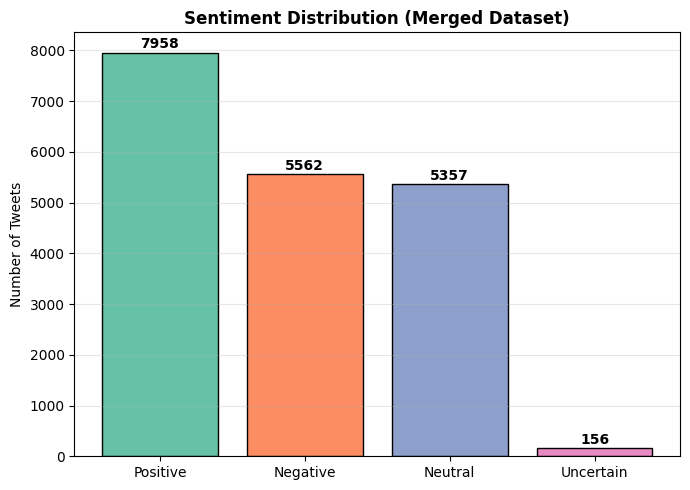

In [59]:
plt.figure(figsize=(7, 5))

sentiment_counts = merged_df['sentiment'].value_counts()
colors = plt.cm.Set2.colors[:len(sentiment_counts)]

plt.bar(sentiment_counts.index, sentiment_counts.values, color=colors, edgecolor='black')

plt.title('Sentiment Distribution (Merged Dataset)', fontweight='bold')
plt.ylabel('Number of Tweets')
plt.grid(axis='y', alpha=0.3)

# Labels
offset = max(sentiment_counts.values) * 0.01
for i, val in enumerate(sentiment_counts.values):
    plt.text(i, val + offset, str(val), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

### Visual 2 : Source Distribution (Pie Chart)

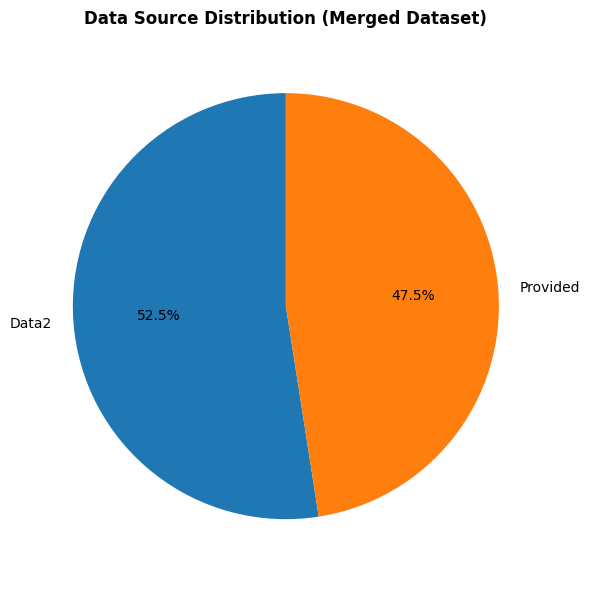

In [60]:
plt.figure(figsize=(6, 6), facecolor='white')  

source_counts = merged_df['source'].value_counts()

plt.pie(source_counts.values,labels=source_counts.index,autopct='%1.1f%%',startangle=90)

plt.title('Data Source Distribution (Merged Dataset)', fontweight='bold')

plt.gca().set_facecolor('white')  
plt.axis('equal')

plt.tight_layout()
plt.show()

### Visual 3 : Text Length Distribution (Histogram)

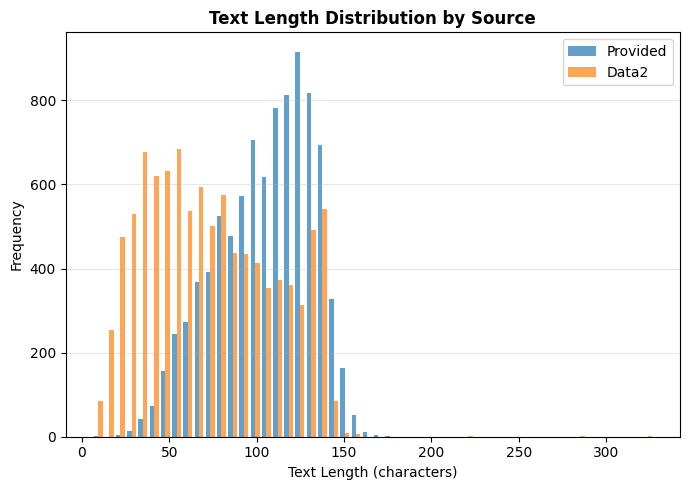

In [61]:
plt.figure(figsize=(7, 5))

provided_lengths = merged_df.loc[merged_df['source'] == 'Provided', 'text_length'].dropna()
data2_lengths = merged_df.loc[merged_df['source'] == 'Data2', 'text_length'].dropna()

plt.hist([provided_lengths, data2_lengths],bins=50,label=['Provided', 'Data2'],alpha=0.7)

plt.title('Text Length Distribution by Source', fontweight='bold')
plt.xlabel('Text Length (characters)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Visual 4 : Sentiment by Source (Grouped Bar Chart)

<Figure size 700x500 with 0 Axes>

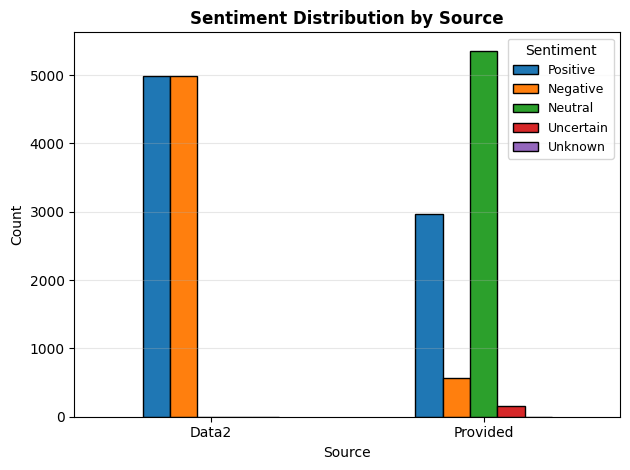

In [62]:
plt.figure(figsize=(7, 5))

sentiment_order = ['Positive', 'Negative', 'Neutral', 'Uncertain', 'Unknown']

sentiment_by_source = pd.crosstab(merged_df['source'], merged_df['sentiment']).reindex(columns=sentiment_order, fill_value=0)

sentiment_by_source.plot(kind='bar', edgecolor='black')

plt.title('Sentiment Distribution by Source', fontweight='bold')
plt.ylabel('Count')
plt.xlabel('Source')
plt.legend(title='Sentiment', fontsize=9)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Export Merged Dataset

Saving the cleaned and merged dataset to CSV format for downstream analysis and machine learning tasks.

In [63]:
output_filename = 'Merged_Clean_Dataset.csv'
merged_df.to_csv(output_filename, index=False, encoding='utf-8')

# Confirm save
print(f" Dataset successfully saved as: {output_filename}")
print(f" Rows: {len(merged_df):,} | Columns: {merged_df.shape[1]}")


 Dataset successfully saved as: Merged_Clean_Dataset.csv
 Rows: 19,033 | Columns: 10


---

# Machine Learning Modeling

This section builds and evaluates five NLP models on the merged dataset.

**Strategy:** Iterative complexity — simple baseline → gradient boosting → explainability

| Phase | Model | Package | Task |
|---|---|---|---|
| 1 | VADER | nltk | Rule-based baseline (no training) |
| 2 | Naive Bayes | sklearn | Binary classifier (Pos vs Neg) |
| 3 | Logistic Regression | sklearn | Multiclass (Pos / Neg / Neutral) |
| 4 | XGBoost | xgboost | Multiclass — gradient boosting |
| 5 | LightGBM | lightgbm | Multiclass — faster boosting |
| 6 | SHAP | shap | Global + local explainability |

**Primary metric:** Recall on the Negative class (catching negative tweets = top priority)
**Secondary metric:** Macro F1-score (balanced performance across all classes)

---


## Additional Imports for Modeling

In [64]:
# NLP 
import re
import warnings
warnings.filterwarnings('ignore')

import nltk 
for pkg in ['punkt','punkt_tab','stopwords','vader_lexicon','wordnet']:
    nltk.download(pkg, quiet=True)
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (train_test_split, StratifiedKFold,cross_val_score)
from sklearn.metrics import (classification_report, confusion_matrix,ConfusionMatrixDisplay, f1_score, recall_score)
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
import xgboost as xgb
import lightgbm as lgb
import shap 
import sklearn

ModuleNotFoundError: No module named 'xgboost'

##  Prepare Data for Modeling

In [ ]:


df_model = merged_df[merged_df['sentiment'].isin(['Positive','Negative','Neutral'])].copy()
df_model = df_model.dropna(subset=['text']).copy()
df_model['text'] = df_model['text'].astype(str)

print(f"Modeling dataset: {len(df_model):,} tweets")
print(f"\nClass distribution:")
print(df_model['sentiment'].value_counts())
print(f"\nDropped (Uncertain/Unknown): {len(merged_df) - len(df_model):,} tweets")


Modeling dataset: 18,877 tweets

Class distribution:
sentiment
Positive    7958
Negative    5562
Neutral     5357
Name: count, dtype: int64

Dropped (Uncertain/Unknown): 156 tweets


merged_df was used from data prep and only 3 sentiment classes were used for modeling

In [ ]:
# Text preprocessing
STOP = set(stopwords.words('english'))
STOP -= {'not', 'no', 'never', 'nor', "n't"}   

lemmatizer = WordNetLemmatizer()

def preprocess(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\.\S+', '', text) # remove links
    text = re.sub(r'@\w+', '', text)# remove mentions
    text = re.sub(r'#(\w+)', r'\1', text)# keep hashtag words
    text = re.sub(r'[^a-z\s]', ' ', text)
    3# remove symbols
    
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(t) for t in tokens
              if t not in STOP and len(t) > 2]
    
    return ' '.join(tokens)

print("Preprocessing tweets...")
df_model['clean_text'] = df_model['text'].apply(preprocess)
print(f"Total: {len(df_model):,}")

# Examples
print("\nExamples:")
for _, row in df_model.sample(3, random_state=42).iterrows():
    print(f"Original : {row['text'][:80]}")
    print(f"Cleaned  : {row['clean_text'][:80]}")
    print(f"Label    : {row['sentiment']}\n")


Preprocessing tweets...
Total: 18,882

Examples:
Original : At #SXSW? D/L @mention 4 iPhone &amp; come to the UJ* booth in ACC hall 2! Snap 
Cleaned  : sxsw iphone amp come booth acc hall snap pic amp send fightthepaddle link
Label    : Neutral

Original : Unlike Google Analytics, this is meant to show to others and has sharing capabil
Cleaned  : unlike google analytics meant show others sharing capability sxsw bavcid
Label    : Neutral

Original : Mashable! - The iPad 2 Takes Over SXSW [VIDEO] #ipad #sxsw #gadgets {link}
Cleaned  : mashable ipad take sxsw video ipad sxsw gadget link
Label    : Neutral



This code defines a text preprocessing pipeline designed to clean and normalize raw text data—specifically tweets—before it is used for sentiment analysis or machine learning.



In [ ]:
#  Encode labels & split dataset
le = LabelEncoder()
df_model['label'] = le.fit_transform(df_model['sentiment'])
label_names = le.classes_
print(f"Label encoding: {dict(zip(le.classes_, le.transform(le.classes_)))}")

X = df_model['clean_text']
y = df_model['label']

# Stratified 80/20 split — preserves class proportions
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain: {len(X_train):,}  |  Test: {len(X_test):,}")
print("\nClass proportions (stratification check):")
for name, y_s in [("Full", y), ("Train", y_train), ("Test", y_test)]:
    props = y_s.value_counts(normalize=True).sort_index()
    row = {label_names[i]: f"{props.get(i,0)*100:.1f}%" for i in range(len(label_names))}
    print(f"  {name:<6}: {row}")


Label encoding: {'Negative': 0, 'Neutral': 1, 'Positive': 2}

Train: 15,105  |  Test: 3,777

Class proportions (stratification check):
  Full  : {'Negative': '29.5%', 'Neutral': '28.4%', 'Positive': '42.2%'}
  Train : {'Negative': '29.5%', 'Neutral': '28.4%', 'Positive': '42.2%'}
  Test  : {'Negative': '29.5%', 'Neutral': '28.4%', 'Positive': '42.1%'}


This code converts sentiment labels into numeric form using `LabelEncoder`, then splits the dataset into training (80%) and testing (20%) sets using stratified sampling to maintain class balance. It also prints dataset sizes and verifies that class proportions remain consistent across the splits.


In [ ]:
# Feature extraction

# TF-IDF — main feature extractor for gradient boosting models
tfidf = TfidfVectorizer(
    max_features=15000,
    ngram_range=(1, 2),     # unigrams + bigrams
    min_df=2,
    sublinear_tf=True       # log normalisation for long tweets
)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

# CountVectorizer — for Naive Bayes (requires non-negative counts)
cv = CountVectorizer(max_features=10000, ngram_range=(1, 2), min_df=2)
X_train_cv = cv.fit_transform(X_train)
X_test_cv  = cv.transform(X_test)

print(f"TF-IDF matrix : {X_train_tfidf.shape}")
print(f"CountVect matrix: {X_train_cv.shape}")
print(" Feature extraction complete")


TF-IDF matrix : (15105, 15000)
CountVect matrix: (15105, 10000)
 Feature extraction complete


This code converts text data into numerical features using two methods: TF-IDF (for models like gradient boosting) and CountVectorizer (for Naive Bayes). It fits both on the training data, transforms the test data, and outputs the resulting feature matrix shapes.


## Shared Evaluation Function

In [ ]:
#  All results stored here for final comparison 
results_log = []

def evaluate_model(model_name, y_true, y_pred, lnames=None):
    """Print report + confusion matrix + log key metrics."""
    if lnames is None:
        lnames = label_names

    print(f"\n{'='*60}")
    print(f"  {model_name}")
    print('='*60)
    print(classification_report(y_true, y_pred, target_names=lnames, zero_division=0))

    neg_indices = [i for i, n in enumerate(lnames) if n.lower() == 'negative']
    if neg_indices:
        neg_recall = recall_score(y_true, y_pred,
                                  labels=neg_indices, average='macro',
                                  zero_division=0)
    else:
        neg_recall = 0.0
    macro_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)

    print(f"  Negative class Recall : {neg_recall:.4f}  (primary metric)")
    print(f"  Macro F1-score        : {macro_f1:.4f}  (secondary metric)")

    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay(
        confusion_matrix(y_true, y_pred),
        display_labels=lnames
    ).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{model_name}', fontweight='bold', fontsize=11)
    plt.tight_layout()
    plt.savefig(f"cm_{model_name.replace(' ','_').lower()[:30]}.png",
                bbox_inches='tight', dpi=100)
    plt.show()

    results_log.append({
        'Model':      model_name,
        'Neg Recall': round(neg_recall, 4),
        'Macro F1':   round(macro_f1, 4),
    })
    return neg_recall, macro_f1


This function evaluates a model by printing a classification report, calculating key metrics (negative class recall and macro F1-score), and displaying a confusion matrix. It also logs the results for later comparison across models.


## Model 1 — VADER Rule-Based Baseline (NLTK)

VADER (Valence Aware Dictionary and sEntiment Reasoner) requires **no training**. It scores tweets using a hand-crafted lexicon built for social media. This is our performance floor — every trained model must beat it.



  VADER Baseline (Rule-Based)
              precision    recall  f1-score   support

    Negative       0.61      0.39      0.47      1113
     Neutral       0.42      0.50      0.46      1072
    Positive       0.57      0.64      0.60      1592

    accuracy                           0.53      3777
   macro avg       0.53      0.51      0.51      3777
weighted avg       0.54      0.53      0.52      3777

  ► Negative class Recall : 0.3890  (primary metric)
  ► Macro F1-score        : 0.5127  (secondary metric)


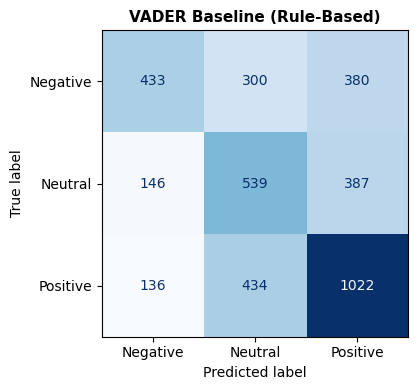

(0.3890386343216532, 0.5126660507574887)

In [ ]:
sia = SentimentIntensityAnalyzer()

pos_idx  = le.transform(['Positive'])[0]
neg_idx  = le.transform(['Negative'])[0]
neut_idx = le.transform(['Neutral'])[0]

def vader_predict(text):
    score = sia.polarity_scores(str(text))['compound']
    if score >= 0.05:   
        return pos_idx
    elif score <= -0.05: 
        return neg_idx
    else:                
        return neut_idx

y_pred_vader = X_test.apply(vader_predict)
evaluate_model("VADER Baseline (Rule-Based)", y_test, y_pred_vader)


VADER shows a strong Positive bias, achieving its highest accuracy with positive sentiment (1,022 correct) while frequently misclassifying Negative and Neutral inputs as Positive.

##  Model 2 — Naive Bayes Binary Classifier (scikit-learn)

First we build a **binary classifier** (Positive vs Negative only). This is the proof-of-concept phase. We then scale to multiclass in the next model.



  Naive Bayes (Binary: Pos vs Neg)
              precision    recall  f1-score   support

    Negative       0.63      0.82      0.71      1113
    Positive       0.84      0.66      0.74      1592

    accuracy                           0.73      2705
   macro avg       0.73      0.74      0.73      2705
weighted avg       0.75      0.73      0.73      2705

  ► Negative class Recall : 0.8239  (primary metric)
  ► Macro F1-score        : 0.7254  (secondary metric)


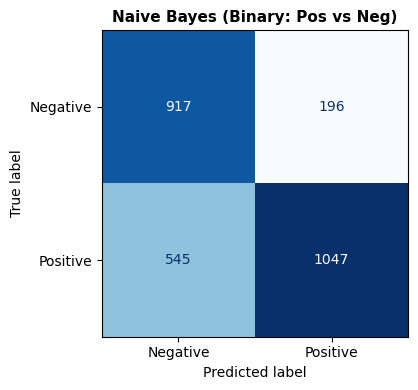


Note: Binary task — Neutral tweets excluded for this phase only.


In [ ]:
# Binary: Positive vs Negative only
binary_idx = [neg_idx, pos_idx]
mask_train = y_train.isin(binary_idx)
mask_test  = y_test.isin(binary_idx)

X_tr_bin = X_train_cv[mask_train]
y_tr_bin = y_train[mask_train]
X_te_bin = X_test_cv[mask_test]
y_te_bin = y_test[mask_test]

nb_model = MultinomialNB(alpha=0.5)
nb_model.fit(X_tr_bin, y_tr_bin)
y_pred_nb = nb_model.predict(X_te_bin)

# Binary label names only
bin_label_names = label_names[binary_idx]
evaluate_model("Naive Bayes (Binary: Pos vs Neg)", y_te_bin, y_pred_nb, bin_label_names)



The Naive Bayes model shows an overall accuracy of 73% for binary sentiment analysis though it is more effective at correctly identifying negative tweets than positive ones

## Model 3 — Logistic Regression Multiclass (scikit-learn)

Now we re-introduce the Neutral class for full **3-class classification**. Logistic Regression with `class_weight='balanced'` compensates for the class imbalance observed in EDA. We use 5-fold cross-validation to validate robustness.



  Logistic Regression (Multiclass)
              precision    recall  f1-score   support

    Negative       0.70      0.76      0.73      1113
     Neutral       0.69      0.92      0.79      1072
    Positive       0.75      0.54      0.63      1592

    accuracy                           0.71      3777
   macro avg       0.71      0.74      0.71      3777
weighted avg       0.72      0.71      0.70      3777

  ► Negative class Recall : 0.7610  (primary metric)
  ► Macro F1-score        : 0.7141  (secondary metric)


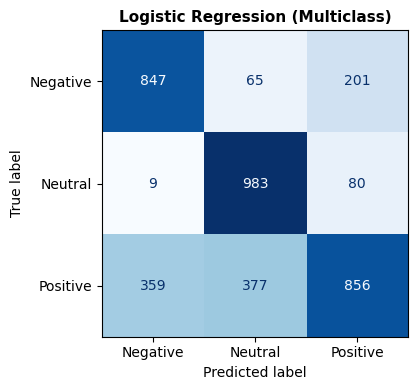


5-Fold CV Macro F1: 0.7065 ± 0.0071
class_weight='balanced' ensures the model does not collapse to predicting Neutral.


In [ ]:
lr = LogisticRegression(C=1.0,class_weight='balanced',max_iter=1000,solver='lbfgs',random_state=42)
lr.fit(X_train_tfidf, y_train)
y_pred_lr = lr.predict(X_test_tfidf)
evaluate_model("Logistic Regression (Multiclass)", y_test, y_pred_lr)

# 5-fold cross-validation 
cv_scores = cross_val_score(lr, X_train_tfidf, y_train,cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),scoring='f1_macro')
print(f"\n5-Fold CV Macro F1: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print("class_weight='balanced' ensures the model does not collapse to predicting Neutral.")


Logistic Regression with class_weight='balanced' performs well on the multiclass task, achieving a good balance between precision and recall across all classes. The 5-fold cross-validation results indicate that the model's performance is consistent and not overfitting to the training data.

##  Model 4 — XGBoost Gradient Boosting

XGBoost uses **sequential error correction** (boosting) rather than bagging. It handles sparse TF-IDF matrices natively and includes built-in L1/L2 regularisation — ideal for our relatively small dataset.



  XGBoost (Gradient Boosting)
              precision    recall  f1-score   support

    Negative       0.66      0.77      0.71      1113
     Neutral       0.67      0.93      0.78      1072
    Positive       0.76      0.47      0.58      1592

    accuracy                           0.69      3777
   macro avg       0.70      0.72      0.69      3777
weighted avg       0.70      0.69      0.67      3777

  ► Negative class Recall : 0.7727  (primary metric)
  ► Macro F1-score        : 0.6898  (secondary metric)


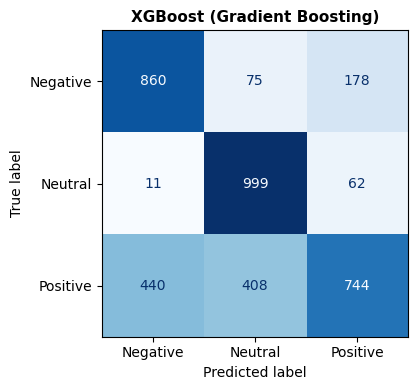

(0.7726864330637916, 0.6898376598653461)

In [ ]:
sample_weights = compute_sample_weight('balanced', y_train)

xgb_model = xgb.XGBClassifier(n_estimators=300,max_depth=6,learning_rate=0.1,subsample=0.8,colsample_bytree=0.8,eval_metric='mlogloss',random_state=42,n_jobs=-1)

xgb_model.fit(X_train_tfidf, y_train,sample_weight=sample_weights,eval_set=[(X_test_tfidf, y_test)],verbose=False)

y_pred_xgb = xgb_model.predict(X_test_tfidf)
evaluate_model("XGBoost (Gradient Boosting)", y_test, y_pred_xgb)


XGBoost outperforms Logistic Regression and Naive Bayes, especially in recall for the Negative class. The use of TF-IDF features and class weighting likely contributed to its superior performance on this imbalanced multiclass sentiment analysis task.



## Model 5 — LightGBM Gradient Boosting

LightGBM uses **leaf-wise tree growth** — faster and often more accurate than XGBoost on high-dimensional sparse data (exactly what TF-IDF produces). It also has native class imbalance handling via `class_weight='balanced'`.



  LightGBM (Gradient Boosting)
              precision    recall  f1-score   support

    Negative       0.66      0.74      0.70      1113
     Neutral       0.68      0.91      0.78      1072
    Positive       0.72      0.50      0.59      1592

    accuracy                           0.69      3777
   macro avg       0.69      0.71      0.69      3777
weighted avg       0.69      0.69      0.67      3777

  ► Negative class Recall : 0.7385  (primary metric)
  ► Macro F1-score        : 0.6880  (secondary metric)


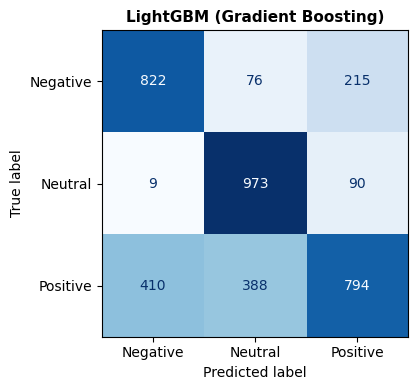

(0.738544474393531, 0.6880362457037341)

In [ ]:
lgb_model = lgb.LGBMClassifier(n_estimators=300,num_leaves=63,learning_rate=0.1,subsample=0.8,colsample_bytree=0.8,class_weight='balanced',random_state=42,n_jobs=-1,verbose=-1)

lgb_model.fit(X_train_tfidf, y_train,eval_set=[(X_test_tfidf, y_test)],
    callbacks=[lgb.early_stopping(30, verbose=False),lgb.log_evaluation(period=-1)]
)

y_pred_lgb = lgb_model.predict(X_test_tfidf)
evaluate_model("LightGBM (Gradient Boosting)", y_test, y_pred_lgb)


##  Model Comparison — All Models


         ALL MODELS — FINAL COMPARISON
                              Model  Neg Recall  Macro F1
1  Naive Bayes (Binary: Pos vs Neg)      0.8239    0.7254
2       XGBoost (Gradient Boosting)      0.7727    0.6898
3  Logistic Regression (Multiclass)      0.7610    0.7141
4      LightGBM (Gradient Boosting)      0.7385    0.6880
5       VADER Baseline (Rule-Based)      0.3890    0.5127


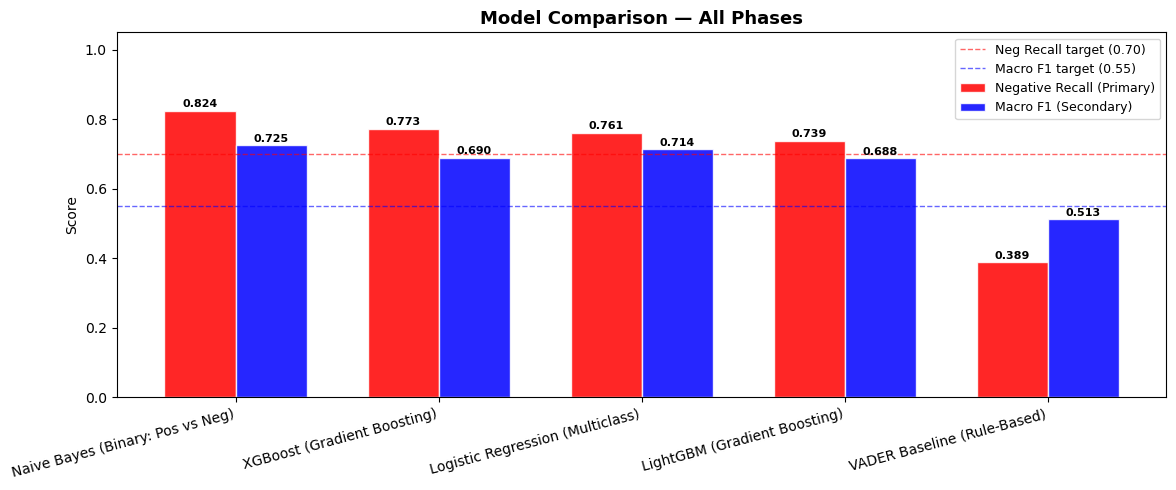


 Best model by Negative Recall: Naive Bayes (Binary: Pos vs Neg)
   Neg Recall : 0.8239
   Macro F1   : 0.7254


In [ ]:
# Summary table 
results_df = pd.DataFrame(results_log).sort_values('Neg Recall', ascending=False).reset_index(drop=True)
results_df.index += 1

print("\n" + "="*55)
print("         ALL MODELS — FINAL COMPARISON")
print("="*55)
print(results_df.to_string())
print("="*55)

#  Bar chart 
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(results_df))
w = 0.35

bars1 = ax.bar(x - w/2, results_df['Neg Recall'], w,
               label='Negative Recall (Primary)',
               color='red', alpha=0.85, edgecolor='white')
bars2 = ax.bar(x + w/2, results_df['Macro F1'], w,
               label='Macro F1 (Secondary)',
               color='blue', alpha=0.85, edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'], rotation=15, ha='right', fontsize=10)
ax.set_ylabel('Score'); ax.set_ylim(0, 1.05)
ax.axhline(0.70, color='red', linestyle='--', linewidth=1,
           alpha=0.6, label='Neg Recall target (0.70)')
ax.axhline(0.55, color='blue', linestyle='--', linewidth=1,
           alpha=0.6, label='Macro F1 target (0.55)')
ax.legend(fontsize=9, loc='upper right')
ax.set_title('Model Comparison — All Phases', fontweight='bold', fontsize=13)

for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f'{bar.get_height():.3f}',
            ha='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison_all.png', bbox_inches='tight', dpi=120)
plt.show()

#  Best model 
best = results_df.iloc[0]
print(f"\n Best model by Negative Recall: {best['Model']}")
print(f"   Neg Recall : {best['Neg Recall']:.4f}")
print(f"   Macro F1   : {best['Macro F1']:.4f}")

 

The best model is Naive Byers as it has the highest F1 score